In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Baseline Forecasting Models

This notebook establishes baseline forecasting models for
daily Fremont Bridge bicycle traffic. These simple models
serve as performance benchmarks that more advanced
forecasting methods must outperform.

The notebook compares multiple baseline forecasting
strategies using standard forecasting error metrics.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from src.evaluation.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    mean_absolute_percentage_error,
)

from src.models.baselines import (
    naive_forecast,
    seasonal_naive_forecast,
    rolling_mean_forecast
)

### Load Modeling Dataset

The processed forecasting dataset is loaded from the
`data/processed` directory. This dataset contains the
daily bicycle traffic observations, weather variables,
and engineered forecasting features developed in the
previous phases of the project.

In [5]:
#Read in data
features_df = pd.read_csv(
    "../data/processed/bike_weather_features.csv"
)

features_df["date"] = pd.to_datetime(
    features_df["date"]
)

In [6]:
#Verify dataset
print(features_df.shape)

features_df.info()

features_df.head()

(4990, 15)
<class 'pandas.DataFrame'>
RangeIndex: 4990 entries, 0 to 4989
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             4990 non-null   datetime64[us]
 1   fremont_bridge   4990 non-null   float64       
 2   temperature_2m   4990 non-null   float64       
 3   precipitation    4990 non-null   float64       
 4   wind_speed_10m   4990 non-null   float64       
 5   day_of_week      4990 non-null   int64         
 6   month            4990 non-null   int64         
 7   year             4990 non-null   int64         
 8   day_of_year      4990 non-null   int64         
 9   month_name       4990 non-null   str           
 10  is_weekend       4990 non-null   int64         
 11  lag_1            4989 non-null   float64       
 12  lag_7            4983 non-null   float64       
 13  rolling_mean_7   4984 non-null   float64       
 14  rolling_mean_30  4961 non-null   float64

,date,fremont_bridge,temperature_2m,precipitation,wind_speed_10m,day_of_week,month,year,day_of_year,month_name,is_weekend,lag_1,lag_7,rolling_mean_7,rolling_mean_30
0,2012-10-02,1938.0,13.300000,0.0,5.654545,1,10,2012,276,October,0,NaN,NaN,NaN,NaN
1,2012-10-03,3521.0,11.495833,0.0,12.845833,2,10,2012,277,October,0,1938.0,NaN,NaN,NaN
2,2012-10-04,3475.0,11.750000,0.0,11.070833,3,10,2012,278,October,0,3521.0,NaN,NaN,NaN
3,2012-10-05,3148.0,12.079167,0.0,9.095833,4,10,2012,279,October,0,3475.0,NaN,NaN,NaN
4,2012-10-06,2006.0,12.454167,0.0,8.541667,5,10,2012,280,October,1,3148.0,NaN,NaN,NaN


### Train-Test Split

The forecasting dataset is divided chronologically into
training and testing sets. The training set contains the
earliest observations and is used to fit forecasting
models, while the testing set contains the most recent
observations and is reserved for evaluating predictive
performance on unseen data.

A chronological split is used instead of a random split
to prevent temporal data leakage and better simulate
real-world forecasting.

In [7]:
# Define the split date
split_date = "2024-06-01"

# Split chronologically
train_df = features_df[features_df["date"] < split_date].copy()

test_df = features_df[features_df["date"] >= split_date].copy()

In [8]:
#Validate data
print("Training Set")
print(train_df["date"].min())
print(train_df["date"].max())
print(train_df.shape)

print()

print("Testing Set")
print(test_df["date"].min())
print(test_df["date"].max())
print(test_df.shape)

Training Set
2012-10-02 00:00:00
2024-05-31 00:00:00
(4260, 15)

Testing Set
2024-06-01 00:00:00
2026-05-31 00:00:00
(730, 15)


### Visualize Train-Test Split

The chronological train-test split is visualized below.
The blue region represents the historical data used to
fit forecasting models, while the orange region
represents the unseen data reserved for evaluation.

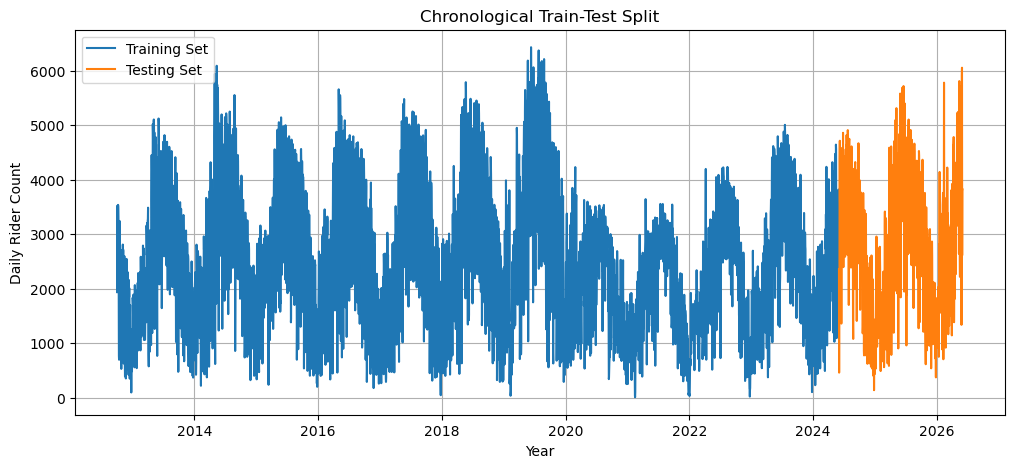

In [9]:
plt.figure(figsize=(12, 5))

plt.plot(
    train_df["date"],
    train_df["fremont_bridge"],
    label="Training Set"
)

plt.plot(
    test_df["date"],
    test_df["fremont_bridge"],
    label="Testing Set"
)

plt.xlabel("Year")
plt.ylabel("Daily Rider Count")
plt.title("Chronological Train-Test Split")
plt.legend()
plt.grid()

plt.show()

## Forecast Evaluation Metrics

Forecasting models are evaluated using quantitative error
metrics that compare predicted values with observed
bicycle traffic. These metrics provide objective measures
of predictive accuracy and allow different forecasting
models to be compared on a common basis.

The evaluation metrics are implemented as reusable
functions within the project source code and are applied
consistently throughout the remainder of the forecasting
pipeline.

### Naïve Forecast

The persistence (naïve) forecasting model predicts each
day's bicycle traffic using the previous day's observed
traffic. This simple benchmark establishes a baseline
against which all subsequent forecasting models will be
compared.

In [10]:
features_df["naive_prediction"] = naive_forecast(features_df["fremont_bridge"])

features_df.head()

,date,fremont_bridge,temperature_2m,precipitation,wind_speed_10m,day_of_week,month,year,day_of_year,month_name,is_weekend,lag_1,lag_7,rolling_mean_7,rolling_mean_30,naive_prediction
0,2012-10-02,1938.0,13.300000,0.0,5.654545,1,10,2012,276,October,0,NaN,NaN,NaN,NaN,NaN
1,2012-10-03,3521.0,11.495833,0.0,12.845833,2,10,2012,277,October,0,1938.0,NaN,NaN,NaN,1938.0
2,2012-10-04,3475.0,11.750000,0.0,11.070833,3,10,2012,278,October,0,3521.0,NaN,NaN,NaN,3521.0
3,2012-10-05,3148.0,12.079167,0.0,9.095833,4,10,2012,279,October,0,3475.0,NaN,NaN,NaN,3475.0
4,2012-10-06,2006.0,12.454167,0.0,8.541667,5,10,2012,280,October,1,3148.0,NaN,NaN,NaN,3148.0


### Evaluate Naïve Forecast

The naïve forecasting model is evaluated using the
chronological test set. Model performance is quantified
using Mean Absolute Error (MAE), Root Mean Squared Error
(RMSE), and Mean Absolute Percentage Error (MAPE).

In [11]:
# Extract the test period
test_predictions = features_df[
    features_df["date"] >= split_date
].copy()

# Remove rows with missing predictions
test_predictions = test_predictions.dropna(
    subset=["naive_prediction"]
)

test_predictions.head()

,date,fremont_bridge,temperature_2m,precipitation,wind_speed_10m,day_of_week,month,year,day_of_year,month_name,is_weekend,lag_1,lag_7,rolling_mean_7,rolling_mean_30,naive_prediction
4260,2024-06-01,2355.0,13.662500,0.4,9.416667,5,6,2024,153,June,1,3578.0,2127.0,2718.000000,2946.100000,3578.0
4261,2024-06-02,462.0,13.666667,12.2,12.987500,6,6,2024,154,June,1,2355.0,1329.0,2594.142857,2862.933333,2355.0
4262,2024-06-03,2051.0,13.104167,14.8,28.308333,0,6,2024,155,June,0,462.0,2728.0,2497.428571,2896.666667,462.0
4263,2024-06-04,2368.0,12.554167,6.8,26.437500,1,6,2024,156,June,0,2051.0,2603.0,2463.857143,2941.333333,2051.0
4264,2024-06-05,4393.0,12.512500,0.3,8.395833,2,6,2024,157,June,0,2368.0,2613.0,2718.142857,3006.400000,2368.0


In [12]:
#Compute metrics
mae = mean_absolute_error(
    test_predictions["fremont_bridge"],
    test_predictions["naive_prediction"]
)

rmse = root_mean_squared_error(
    test_predictions["fremont_bridge"],
    test_predictions["naive_prediction"]
)

mape = mean_absolute_percentage_error(
    test_predictions["fremont_bridge"],
    test_predictions["naive_prediction"]
)

print(f"MAE  : {mae:.2f} riders")
print(f"RMSE : {rmse:.2f} riders")
print(f"MAPE : {mape:.2f}%")

MAE  : 713.51 riders
RMSE : 924.71 riders
MAPE : 34.08%


### Visualize Naïve Forecast

The predicted and observed bicycle traffic are compared
over a portion of the testing period to qualitatively
assess forecasting performance.

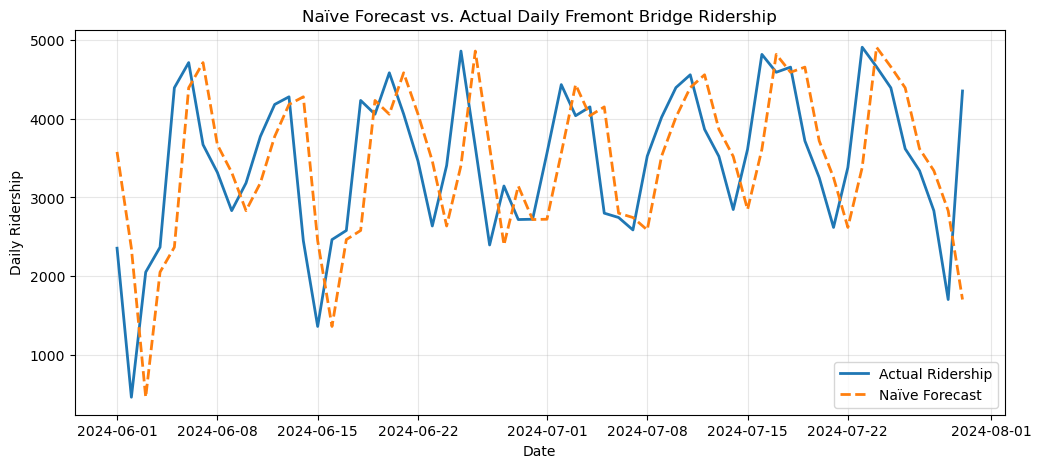

In [13]:
plot_df = test_predictions.iloc[:60] #look at subsection only

plt.figure(figsize=(12, 5))

plt.plot(
    plot_df["date"],
    plot_df["fremont_bridge"],
    label="Actual Ridership",
    linewidth=2
)

plt.plot(
    plot_df["date"],
    plot_df["naive_prediction"],
    label="Naïve Forecast",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Date")
plt.ylabel("Daily Ridership")
plt.title(
    "Naïve Forecast vs. Actual Daily Fremont Bridge Ridership"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout

plt.savefig(
    "../reports/figures/naive_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



#### Interpretation

The persistence (naïve) forecast provides a simple benchmark
for daily bicycle traffic prediction. While the model
captures short-term temporal dependence by using the
previous day's traffic as its prediction, it does not
account for the strong weekly commuting patterns observed
during exploratory data analysis.

The relatively large forecasting errors suggest that
additional temporal structure, particularly weekly
seasonality, should improve predictive performance. The
next baseline model incorporates this information by
predicting each day's traffic using the observation from
one week earlier.

### Seasonal Naïve Forecast

The seasonal naïve forecasting model predicts each day's
bicycle traffic using the observed traffic from the same
day one week earlier. This approach incorporates the
weekly seasonality identified during exploratory data
analysis and serves as a stronger baseline than the
simple persistence forecast.

Mathematically, the seasonal naïve forecast is defined as

$$
\hat{y}_t = y_{t-7}
$$

where $\hat{y}_t$ is the predicted bicycle traffic for day
$t$, and $y_{t-7}$ is the observed traffic one week
earlier.



In [14]:
#Generate seasonal prediction and validate
features_df["seasonal_prediction"] = (
    seasonal_naive_forecast(
        features_df["fremont_bridge"]
    )
)

features_df[["date", "fremont_bridge", "seasonal_prediction"]].head(15)

,date,fremont_bridge,seasonal_prediction
0,2012-10-02,1938.0,NaN
1,2012-10-03,3521.0,NaN
2,2012-10-04,3475.0,NaN
3,2012-10-05,3148.0,NaN
4,2012-10-06,2006.0,NaN
5,2012-10-07,2142.0,NaN
6,2012-10-08,3537.0,NaN
7,2012-10-09,3501.0,1938.0
8,2012-10-10,3235.0,3521.0
9,2012-10-11,3047.0,3475.0


### Evaluate Seasonal Naïve Forecast

The seasonal naïve forecasting model is evaluated using
the chronological test set. Performance is quantified
using Mean Absolute Error (MAE), Root Mean Squared Error
(RMSE), and Mean Absolute Percentage Error (MAPE).

In [15]:
# Extract the test period
seasonal_test = features_df[
    features_df["date"] >= split_date
].copy()

# Remove rows with missing predictions
season_test = seasonal_test.dropna(
    subset=["naive_prediction"]
)

seasonal_test.head()

,date,fremont_bridge,temperature_2m,precipitation,wind_speed_10m,day_of_week,month,year,day_of_year,month_name,is_weekend,lag_1,lag_7,rolling_mean_7,rolling_mean_30,naive_prediction,seasonal_prediction
4260,2024-06-01,2355.0,13.662500,0.4,9.416667,5,6,2024,153,June,1,3578.0,2127.0,2718.000000,2946.100000,3578.0,2127.0
4261,2024-06-02,462.0,13.666667,12.2,12.987500,6,6,2024,154,June,1,2355.0,1329.0,2594.142857,2862.933333,2355.0,1329.0
4262,2024-06-03,2051.0,13.104167,14.8,28.308333,0,6,2024,155,June,0,462.0,2728.0,2497.428571,2896.666667,462.0,2728.0
4263,2024-06-04,2368.0,12.554167,6.8,26.437500,1,6,2024,156,June,0,2051.0,2603.0,2463.857143,2941.333333,2051.0,2603.0
4264,2024-06-05,4393.0,12.512500,0.3,8.395833,2,6,2024,157,June,0,2368.0,2613.0,2718.142857,3006.400000,2368.0,2613.0


In [16]:
#Compute metrics
seasonal_mae = mean_absolute_error(
    seasonal_test["fremont_bridge"],
    seasonal_test["seasonal_prediction"]
)

seasonal_rmse = root_mean_squared_error(
    seasonal_test["fremont_bridge"],
    season_test["seasonal_prediction"]
)

seasonal_mape = mean_absolute_percentage_error(
    seasonal_test["fremont_bridge"],
    seasonal_test["seasonal_prediction"]
)

print(f"MAE  : {seasonal_mae:.2f} riders")
print(f"RMSE : {seasonal_rmse:.2f} riders")
print(f"MAPE : {seasonal_mape:.2f}%")

MAE  : 680.75 riders
RMSE : 915.13 riders
MAPE : 34.43%


### Visualize the Seasonal Forecast


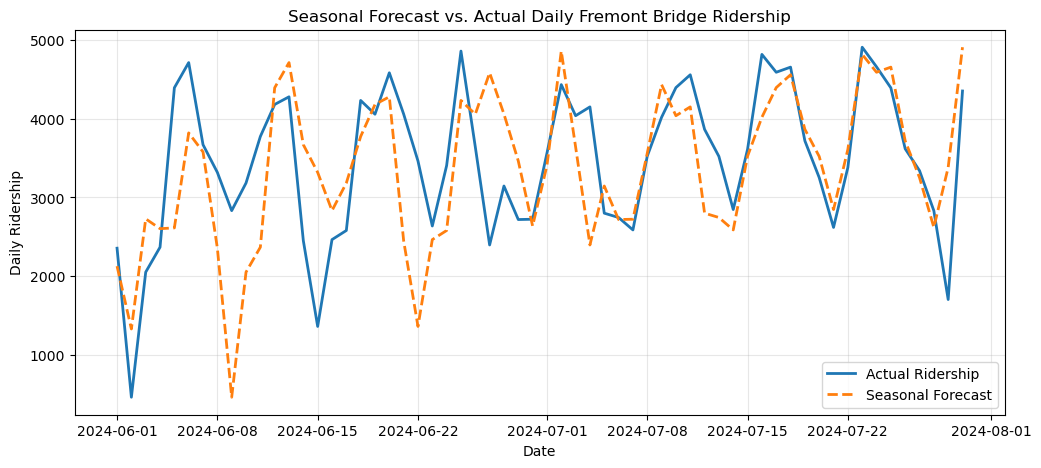

In [17]:
plot_df = seasonal_test.iloc[:60] #look at subsection only

plt.figure(figsize=(12, 5))

plt.plot(
    plot_df["date"],
    plot_df["fremont_bridge"],
    label="Actual Ridership",
    linewidth=2
)

plt.plot(
    plot_df["date"],
    plot_df["seasonal_prediction"],
    label="Seasonal Forecast",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Date")
plt.ylabel("Daily Ridership")
plt.title(
    "Seasonal Forecast vs. Actual Daily Fremont Bridge Ridership"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout

plt.savefig(
    "../reports/figures/seasonal_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


#### Interpretation

The Seasonal Naïve model reproduces the weekly variability in bicycle traffic more faithfully than the persistence forecast by using observations from the same weekday one week earlier. As a result, it captures the recurring commuter cycle but can still produce large errors when traffic differs substantially from the previous week due to weather, holidays, or other non-recurring events.

### Rolling Mean Forecast

The rolling mean forecasting model predicts each day's
bicycle traffic using the average bicycle traffic over
the previous seven days. By averaging multiple recent
observations, the model reduces short-term variability
and produces smoother forecasts than the persistence and
seasonal naïve models.

Mathematically, the rolling mean forecast is defined as

$$ \hat{y}_t = \frac{1}{7}\sum_{i=1}^{7}y_{t-i}$$

where $\hat{y}_t$ is the predicted bicycle traffic for day
$t$, and the prediction is computed as the mean of the
previous seven observed daily traffic counts.

In [19]:
features_df["rolling_prediction"] = (
    rolling_mean_forecast(
        features_df["fremont_bridge"]
    )
)

features_df[ ["date", "fremont_bridge", "rolling_prediction"] ].head(15)

,date,fremont_bridge,rolling_prediction
0,2012-10-02,1938.0,NaN
1,2012-10-03,3521.0,NaN
2,2012-10-04,3475.0,NaN
3,2012-10-05,3148.0,NaN
4,2012-10-06,2006.0,NaN
5,2012-10-07,2142.0,NaN
6,2012-10-08,3537.0,NaN
7,2012-10-09,3501.0,2823.857143
8,2012-10-10,3235.0,3047.142857
9,2012-10-11,3047.0,3006.285714


### Evaluate Rolling Mean Forecast

The rolling mean forecasting model is evaluated using
the chronological test set. Performance is quantified
using Mean Absolute Error (MAE), Root Mean Squared Error
(RMSE), and Mean Absolute Percentage Error (MAPE).

In [21]:
#Get test data
rolling_test = features_df[
    features_df["date"] >= split_date
].copy()

rolling_test = rolling_test.dropna(
    subset=["rolling_prediction"]
)

rolling_test.head()

,date,fremont_bridge,temperature_2m,precipitation,wind_speed_10m,day_of_week,month,year,day_of_year,month_name,is_weekend,lag_1,lag_7,rolling_mean_7,rolling_mean_30,naive_prediction,seasonal_prediction,rolling_prediction
4260,2024-06-01,2355.0,13.662500,0.4,9.416667,5,6,2024,153,June,1,3578.0,2127.0,2718.000000,2946.100000,3578.0,2127.0,2685.428571
4261,2024-06-02,462.0,13.666667,12.2,12.987500,6,6,2024,154,June,1,2355.0,1329.0,2594.142857,2862.933333,2355.0,1329.0,2718.000000
4262,2024-06-03,2051.0,13.104167,14.8,28.308333,0,6,2024,155,June,0,462.0,2728.0,2497.428571,2896.666667,462.0,2728.0,2594.142857
4263,2024-06-04,2368.0,12.554167,6.8,26.437500,1,6,2024,156,June,0,2051.0,2603.0,2463.857143,2941.333333,2051.0,2603.0,2497.428571
4264,2024-06-05,4393.0,12.512500,0.3,8.395833,2,6,2024,157,June,0,2368.0,2613.0,2718.142857,3006.400000,2368.0,2613.0,2463.857143


In [23]:
#compute metrics
rolling_mae = mean_absolute_error(
    rolling_test["fremont_bridge"],
    rolling_test["rolling_prediction"]
)

rolling_rmse = root_mean_squared_error(
    rolling_test["fremont_bridge"],
    rolling_test["rolling_prediction"]
)

rolling_mape = mean_absolute_percentage_error(
    rolling_test["fremont_bridge"],
    rolling_test["rolling_prediction"]
)

print(f"MAE  : {rolling_mae:.2f} riders")
print(f"RMSE : {rolling_rmse:.2f} riders")
print(f"MAPE : {rolling_mape:.2f}%")

MAE  : 724.99 riders
RMSE : 904.64 riders
MAPE : 37.40%


### Visualize the Rolling Forecast

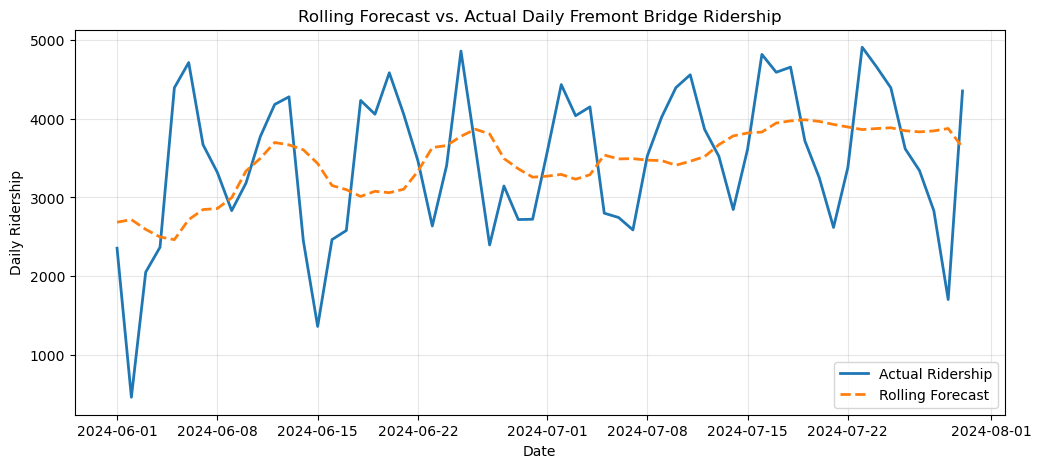

In [26]:
plot_df = rolling_test.iloc[:60] #look at subsection only

plt.figure(figsize=(12, 5))

plt.plot(
    plot_df["date"],
    plot_df["fremont_bridge"],
    label="Actual Ridership",
    linewidth=2
)

plt.plot(
    plot_df["date"],
    plot_df["rolling_prediction"],
    label="Rolling Forecast",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Date")
plt.ylabel("Daily Ridership")
plt.title(
    "Rolling Forecast vs. Actual Daily Fremont Bridge Ridership"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout

plt.savefig(
    "../reports/figures/rolling_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


#### Interpretation

The rolling mean forecast captures the overall trend in bicycle traffic by averaging the previous seven days of observations, producing a smoother prediction than either the naïve or seasonal naïve models. As a result, the forecast reduces the influence of short-term fluctuations and isolated spikes, but it also smooths over the pronounced weekday and weekend commuting cycle. Consequently, the model tends to underestimate periods of high ridership and overestimate periods of low ridership, limiting its ability to reproduce the day-to-day variability observed in the data.

### Baseline Model Comparison and Discussion

The three baseline forecasting models are compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE). Together, these metrics provide complementary measures of forecasting performance and establish benchmarks for more
advanced forecasting models.

In [25]:
results = pd.DataFrame(
    {
        "Model": [
            "Naïve",
            "Seasonal Naïve",
            "Rolling Mean"
        ],
        "MAE": [
            mae,
            seasonal_mae,
            rolling_mae
        ],
        "RMSE": [
            rmse,
            seasonal_rmse,
            rolling_rmse
        ],
        "MAPE": [
            mape,
            seasonal_mape,
            rolling_mape
        ]
    }
)

results.round(2)

,Model,MAE,RMSE,MAPE
0,Naïve,713.51,924.71,34.08
1,Seasonal Naïve,680.75,915.13,34.43
2,Rolling Mean,724.99,904.64,37.40


The three baseline models reveal complementary aspects of the forecasting problem. The Seasonal Naïve model achieved the lowest Mean Absolute Error, demonstrating that weekly seasonality is one of the strongest predictors of bicycle traffic. The Rolling Mean model produced the lowest Root Mean Squared Error, indicating that smoothing recent observations reduces the impact of large forecasting errors. However, its higher Mean Absolute Percentage Error suggests that averaging across weekdays and weekends reduces proportional accuracy during periods of low ridership. Overall, the baseline experiments confirm that preserving weekly temporal structure is more informative than simply smoothing recent observations, providing a strong foundation for more advanced forecasting models such as SARIMA and machine learning approaches.